# Comparación: CNN Funcional vs CNN Profunda y Red Siamés (MNIST)

**Objetivo:**  
1. Comparar dos arquitecturas CNN (modelo funcional base y una versión profunda con 4 convolucionales) entrenadas con MNIST bajo las mismas condiciones.  
2. Entrenar una red siamés con *contrastive loss* usando pares positivos/negativos generados a partir de MNIST.  
3. Realizar una comparación avanzada que relacione las predicciones de las CNN con las distancias aprendidas por la red siamés.

**Instrucciones de uso:**  
- Este notebook está listo para subir a Google Colab.  
- Ejecuta todas las celdas en orden.  
- Ajusta `epochs` y `batch_size` según tus recursos en Colab (GPU recomendado).  


In [1]:
# =========================
# 0) IMPORTS Y CONFIGURACIÓN
# =========================
# Importamos librerías básicas y Keras/TensorFlow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

# Configuración estética para gráficas
sns.set(font_scale=1.2)
plt.style.use('seaborn-v0_8-darkgrid')

# Fijamos una semilla para reproducibilidad (opcional)
np.random.seed(42)
tf.random.set_seed(42)

print('Librerías cargadas correctamente. TensorFlow version:', tf.__version__)


Librerías cargadas correctamente. TensorFlow version: 2.19.0


In [2]:
# ============================================
# 1) CARGA Y PREPROCESAMIENTO DEL DATASET MNIST
# ============================================
# Cargamos MNIST (imágenes 28x28 de dígitos 0-9)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizamos los pixeles a rango [0,1] y convertimos a float32
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Añadimos el canal de profundidad (1) → shape (N,28,28,1)
X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)

# Convertimos etiquetas a one-hot para clasificación con las CNNs
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

print('Shapes:')
print('  X_train:', X_train.shape)
print('  X_test :', X_test.shape)
print('  y_train (categorical):', y_train_cat.shape)
print('  y_test (categorical):', y_test_cat.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shapes:
  X_train: (60000, 28, 28, 1)
  X_test : (10000, 28, 28, 1)
  y_train (categorical): (60000, 10)
  y_test (categorical): (10000, 10)


In [3]:
# ============================================
# 2) DEFINICIÓN DE MODELOS CNN (FUNCIONAL Y PROFUNDO)
# ============================================
# MODELO A: CNN Funcional (base)
inputs1 = Input(shape=(28,28,1), name='input_funcional')
# Primera convolución + pooling
x1 = Conv2D(64, (3,3), activation='relu', name='conv1')(inputs1)  # 64 filtros 3x3
x1 = MaxPooling2D((2,2), name='pool1')(x1)                         # reduce espacialmente
# Segunda convolución + pooling
x1 = Conv2D(128, (3,3), activation='relu', name='conv2')(x1)      # 128 filtros 3x3
x1 = MaxPooling2D((2,2), name='pool2')(x1)
# Capa final densa
x1 = Flatten(name='flatten')(x1)
x1 = Dense(128, activation='relu', name='dense_128')(x1)
outputs1 = Dense(10, activation='softmax', name='output')(x1)

cnn_funcional = Model(inputs1, outputs1, name='CNN_Funcional')
cnn_funcional.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# MODELO B: CNN Profunda (2 conv + pool, luego otras 2 conv + pool)
inputs2 = Input(shape=(28,28,1), name='input_profundo')
# Bloque 1: 2 convoluciones seguidas y pooling
x2 = Conv2D(32, (3,3), activation='relu', padding='same', name='conv2d_1')(inputs2)
x2 = Conv2D(64, (3,3), activation='relu', padding='same', name='conv2d_2')(x2)
x2 = MaxPooling2D((2,2), name='maxpool_1')(x2)
# Bloque 2: otras 2 convoluciones y pooling
x2 = Conv2D(128, (3,3), activation='relu', padding='same', name='conv2d_3')(x2)
x2 = Conv2D(256, (3,3), activation='relu', padding='same', name='conv2d_4')(x2)
x2 = MaxPooling2D((2,2), name='maxpool_2')(x2)
# Final
x2 = Flatten(name='flatten')(x2)
x2 = Dense(256, activation='relu', name='dense_256')(x2)
outputs2 = Dense(10, activation='softmax', name='output')(x2)

cnn_profundo = Model(inputs2, outputs2, name='CNN_Profundo')
cnn_profundo.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

print('\nModelos creados: CNN Funcional y CNN Profundo')



Modelos creados: CNN Funcional y CNN Profundo


In [4]:
# Mostrar resúmenes (arquitectura y parámetros)
print('\n--- Resumen: CNN Funcional ---')
cnn_funcional.summary()
print('\n--- Resumen: CNN Profundo ---')
cnn_profundo.summary()



--- Resumen: CNN Funcional ---


Model: "CNN_Funcional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_funcional (InputLayer)    │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,514 (1.85 MB)

 Trainable params: 485,514 (1.85 MB)

...

Model: "CNN_Profundo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_profundo (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,601,930 (13.74 MB)

 Trainable params: 3,601,930 (13.74 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ============================================
# 3) ENTRENAMIENTO: ambos modelos con mismas condiciones
# ============================================
epochs = 50        # Ajusta según recurso (Colab GPU: sube si quieres)
batch_size = 128

# Entrenamos primero la CNN funcional
history_funcional = cnn_funcional.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# Entrenamos la CNN profunda (mismas condiciones)
history_profundo = cnn_profundo.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)


Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8704 - loss: 0.4319 - val_accuracy: 0.9835 - val_loss: 0.0580
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9838 - loss: 0.0519 - val_accuracy: 0.9887 - val_loss: 0.0388
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9895 - loss: 0.0345 - val_accuracy: 0.9868 - val_loss: 0.0389
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9923 - loss: 0.0254 - val_accuracy: 0.9893 - val_loss: 0.0350
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9945 - loss: 0.0190 - val_accuracy: 0.9907 - val_loss: 0.0365
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9964 - loss: 0.0138 - val_accuracy: 0.9902 - val_loss: 0.0441
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9968 - loss: 0.0107 - val_accuracy: 0.9908 - val_loss: 0.0426
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9973 - loss: 0.0084 - val_accuracy: 

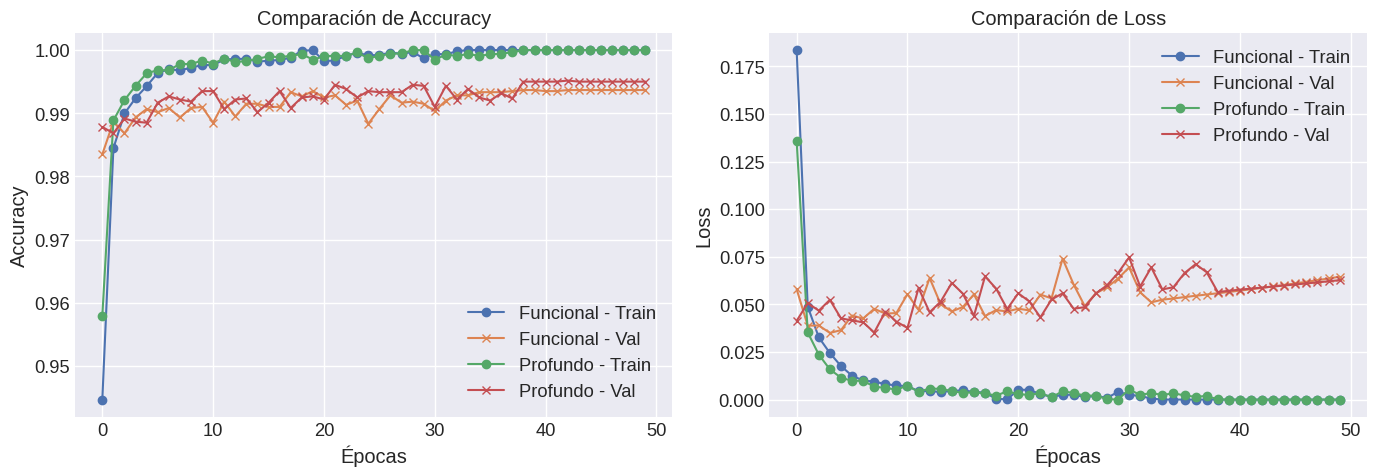

In [6]:
# ============================================
# 4) COMPARACIÓN VISUAL: Accuracy y Loss
# ============================================
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_funcional.history['accuracy'], marker='o', label='Funcional - Train')
plt.plot(history_funcional.history['val_accuracy'], marker='x', label='Funcional - Val')
plt.plot(history_profundo.history['accuracy'], marker='o', label='Profundo - Train')
plt.plot(history_profundo.history['val_accuracy'], marker='x', label='Profundo - Val')
plt.title('Comparación de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_funcional.history['loss'], marker='o', label='Funcional - Train')
plt.plot(history_funcional.history['val_loss'], marker='x', label='Funcional - Val')
plt.plot(history_profundo.history['loss'], marker='o', label='Profundo - Train')
plt.plot(history_profundo.history['val_loss'], marker='x', label='Profundo - Val')
plt.title('Comparación de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [7]:
# ============================================
# 5) EVALUACIÓN FINAL: métricas en test set
# ============================================
loss_f, acc_f = cnn_funcional.evaluate(X_test, y_test_cat, verbose=0)
loss_p, acc_p = cnn_profundo.evaluate(X_test, y_test_cat, verbose=0)

print('\nRESULTADOS EN TEST:')
print(f'CNN Funcional -> Loss: {loss_f:.4f}, Accuracy: {acc_f:.4f}')
print(f'CNN Profundo  -> Loss: {loss_p:.4f}, Accuracy: {acc_p:.4f}')

if acc_p > acc_f:
    print('\n✅ La CNN profunda tiene mejor rendimiento general.')
else:
    print('\n📉 La CNN funcional conserva mejor precisión o estabilidad.')



RESULTADOS EN TEST:
CNN Funcional -> Loss: 0.0500, Accuracy: 0.9932
CNN Profundo  -> Loss: 0.0370, Accuracy: 0.9952

✅ La CNN profunda tiene mejor rendimiento general.


In [8]:
# ============================================
# 6) MODELO SIAMÉS - PREPARACIÓN DE PARES
# ============================================
# Aquí generamos pares positivos (mismo dígito) y negativos (dígitos distintos)
def make_pairs(images, labels):
    num_classes = 10
    digit_indices = [np.where(labels == i)[0] for i in range(num_classes)]
    pairs = []
    pair_labels = []
    # Recorremos cada imagen y construimos un par positivo y uno negativo
    for idx, img in enumerate(images):
        label = labels[idx]
        # positivo: otra imagen con la misma etiqueta
        pos_idx = np.random.choice(digit_indices[label])
        pos_img = images[pos_idx]
        # negativo: imagen con etiqueta distinta
        neg_label = (label + np.random.randint(1, num_classes)) % num_classes
        neg_idx = np.random.choice(digit_indices[neg_label])
        neg_img = images[neg_idx]
        pairs.append([img, pos_img])
        pair_labels.append(1.0)  # 1 → similar
        pairs.append([img, neg_img])
        pair_labels.append(0.0)  # 0 → distinto
    return np.array(pairs), np.array(pair_labels).astype('float32')

# Cargamos MNIST crudo (no one-hot) para pares
(x_train_pairs, y_train_pairs), (x_test_pairs, y_test_pairs) = mnist.load_data()
x_train_pairs = x_train_pairs.astype('float32') / 255.0
x_test_pairs  = x_test_pairs.astype('float32')  / 255.0
x_train_pairs = np.expand_dims(x_train_pairs, -1)
x_test_pairs  = np.expand_dims(x_test_pairs, -1)

# Generamos pares (esto duplica las muestras: 2 pares por imagen)
train_pairs, train_pair_labels = make_pairs(x_train_pairs, y_train_pairs)
test_pairs, test_pair_labels   = make_pairs(x_test_pairs, y_test_pairs)

print('Pares generados:')
print('  train_pairs shape:', train_pairs.shape)
print('  test_pairs  shape:', test_pairs.shape)


Pares generados:
  train_pairs shape: (120000, 2, 28, 28, 1)
  test_pairs  shape: (20000, 2, 28, 28, 1)


In [9]:
# ============================================
# 7) ENCODER (SUBRED) Y MODELO SIAMÉS
# ============================================
def build_encoder():
    inputs = tf.keras.Input((28,28,1))
    x = layers.Conv2D(64, (3,3), activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(64)(x)  # embedding vector (64 dims)
    return Model(inputs, outputs, name='Encoder')

encoder = build_encoder()
encoder.summary()

# Entradas del siamés: dos imágenes
input_A = layers.Input((28,28,1))
input_B = layers.Input((28,28,1))

# Pasamos ambas por el encoder compartido
emb_A = encoder(input_A)
emb_B = encoder(input_B)

# Distancia euclidiana entre embeddings
distance = layers.Lambda(
    lambda tensors: tf.sqrt(
        tf.reduce_sum(tf.square(tensors[0] - tensors[1]), axis=1, keepdims=True) + 1e-9
    )
)([emb_A, emb_B])


siamese_network = Model([input_A, input_B], distance, name='SiameseNet')
siamese_network.summary()


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 492,480 (1.88 MB)

 Trainable params: 492,480 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

Model: "SiameseNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder             │ (None, 64)        │    492,480 │ input_layer_1[0]… │
│ (Functional)        │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ Encoder[0][0],    │
│                     │                   │            │ Encoder[1][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 492,480 (1.88 MB)

 Trainable params: 492,480 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ============================================
# 8) PÉRDIDA CONTRASTIVA Y COMPILACIÓN
# ============================================
def contrastive_loss(y_true, y_pred, margin=1.0):
    # y_true: 1.0 si similar, 0.0 si distinto
    square_pred = tf.square(y_pred)
    margin_square = tf.square(tf.maximum(margin - y_pred, 0.0))
    return tf.reduce_mean(y_true * square_pred + (1.0 - y_true) * margin_square)

siamese_network.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss=contrastive_loss)
print('Siamese compilado con contrastive_loss.')


Siamese compilado con contrastive_loss.


In [11]:
# ============================================
# 9) ENTRENAMIENTO DEL MODELO SIAMÉS
# ============================================
# Nota: reduce epochs si estás en entorno con recursos limitados
epochs_siamese = 50
batch_size_siamese = 128

history_siamese = siamese_network.fit(
    [train_pairs[:,0], train_pairs[:,1]], train_pair_labels,
    validation_data=([test_pairs[:,0], test_pairs[:,1]], test_pair_labels),
    epochs=epochs_siamese,
    batch_size=batch_size_siamese,
    verbose=1
)


Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.0662 - val_loss: 0.0218
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0181 - val_loss: 0.0172
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0121 - val_loss: 0.0155
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0091 - val_loss: 0.0149
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0072 - val_loss: 0.0144
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0058 - val_loss: 0.0141
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0048 - val_loss: 0.0137
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0041 - val_loss: 0.0134
Epoch 9/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0036 - val_loss: 0.0132
Epoch 10/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0032 - val_loss: 0.0133
Epoch 11/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0029 - val_loss: 0.0129
Epoch 12/50
938/938 ━━━━━━━━━━

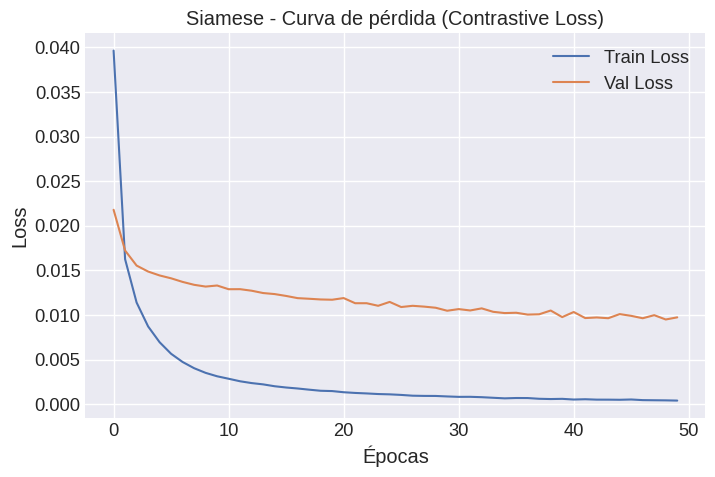

In [12]:
# ============================================
# 10) CURVA DE PÉRDIDA DEL SIAMÉS
# ============================================
plt.figure(figsize=(8,5))
plt.plot(history_siamese.history['loss'], label='Train Loss')
plt.plot(history_siamese.history['val_loss'], label='Val Loss')
plt.title('Siamese - Curva de pérdida (Contrastive Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Ejemplo - primeras 10 predicciones (CNN Funcional): [7 2 1 0 4 1 4 9 5 9]
Ejemplo - primeras 10 predicciones (CNN Profundo) : [7 2 1 0 4 1 4 9 5 9]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step


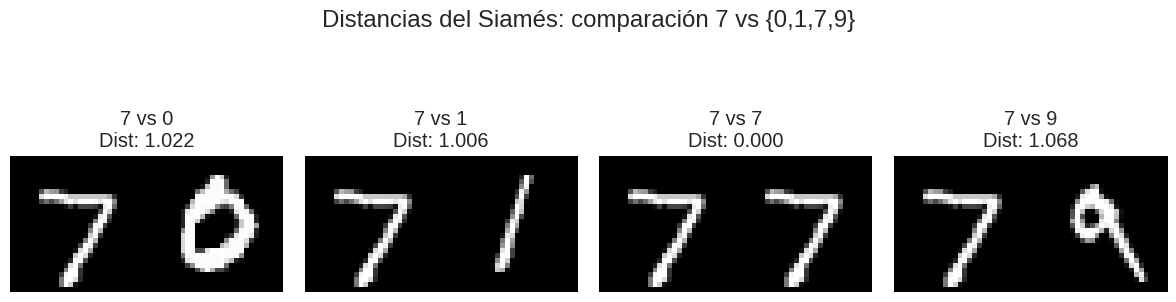


Interpretación:
- Distancias pequeñas indican similitud según el siamés.
- Verifica si las CNN clasifican correctamente los pares similares/diferentes.


In [13]:
# ============================================
# 11) COMPARACIÓN AVANZADA: CNNs vs SIAMÉS
# ============================================
# Elegimos algunos dígitos y ejemplos para comparar sus embeddings/distancias
# Usaremos X_test y y_test_cat del entrenamiento CNN y test_pairs del siamés

# Aseguramos que existan suficientes ejemplos
num_samples = 5
digits_to_compare = [0,1,7,9]
samples = {}

# Extraemos ejemplos del test set (etiquetas en formato entero y one-hot)
y_test_int = np.argmax(y_test_cat, axis=1)

for d in digits_to_compare:
    idxs = np.where(y_test_int == d)[0][:num_samples]
    samples[d] = X_test[idxs]

# Predicciones de las CNN (para las primeras 1000 muestras)
preds_func = cnn_funcional.predict(X_test[:1000])
preds_prof = cnn_profundo.predict(X_test[:1000])

pred_labels_func = np.argmax(preds_func, axis=1)
pred_labels_prof = np.argmax(preds_prof, axis=1)

print('Ejemplo - primeras 10 predicciones (CNN Funcional):', pred_labels_func[:10])
print('Ejemplo - primeras 10 predicciones (CNN Profundo) :', pred_labels_prof[:10])

# Tomamos una imagen base (por ejemplo un '7') y comparamos con otros dígitos
base_img = samples[7][0]  # primer ejemplo de '7'
comparison_imgs = [samples[d][0] for d in digits_to_compare]  # imgs 0,1,7,9

# Calculamos distancias con el siamés
distances = siamese_network.predict([
    np.repeat(base_img[np.newaxis,...], len(comparison_imgs), axis=0),
    np.array(comparison_imgs)
])

# Visualizamos
plt.figure(figsize=(12,4))
for i, d in enumerate(digits_to_compare):
    plt.subplot(1, len(digits_to_compare), i+1)
    concat = np.concatenate([base_img.squeeze(), comparison_imgs[i].squeeze()], axis=1)
    plt.imshow(concat, cmap='gray')
    plt.title(f'7 vs {d}\nDist: {distances[i][0]:.3f}')
    plt.axis('off')
plt.suptitle('Distancias del Siamés: comparación 7 vs {0,1,7,9}')
plt.tight_layout()
plt.show()

# Interpretación rápida
print('\nInterpretación:')
print('- Distancias pequeñas indican similitud según el siamés.')
print('- Verifica si las CNN clasifican correctamente los pares similares/diferentes.')


## Referencias
- Keras API Documentation: https://keras.io/api/  
- TensorFlow MNIST Dataset: https://www.tensorflow.org/datasets/catalog/mnist  
- Keras Example: Siamese Network with Contrastive Loss: https://keras.io/examples/vision/siamese_contrastive  
- Hadsell, R., Chopra, S., & LeCun, Y. (2006). *Dimensionality Reduction by Learning an Invariant Mapping.* CVPR 2006.  
- Chollet, F. (2017). *Deep Learning with Python.* Manning Publications.  
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning.* MIT Press.
